In [1]:
#Créer les variables clients + segmentation K-Means

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Charger les données
customers = pd.read_csv("../data/raw/customers_data.csv")
sales = pd.read_csv("../data/raw/sales_data.csv")

# Calculer le revenu des ventes
sales["Revenue"] = sales["Quantity"] * sales["Sale_Price"]

In [3]:
#Créer les features
customer_features = customers[
    ["Customer_ID", "Age", "Total_Spent"]
].copy()

In [4]:
#Nombre d'achats :
purchase_count = (
    sales.groupby("Customer_ID")
    .size()
    .rename("Number_of_Purchases")
)

In [5]:
#Quantité totale :
quantity = (
    sales.groupby("Customer_ID")["Quantity"]
    .sum()
    .rename("Total_Quantity")
)

In [6]:
#Valeur moyenne d'une vente :

In [7]:
average_sale = (
    sales.groupby("Customer_ID")["Revenue"]
    .mean()
    .rename("Average_Sale_Value")
)

In [8]:
#Fusion :
customer_features = customer_features.merge(
    purchase_count,
    on="Customer_ID",
    how="left"
)

customer_features = customer_features.merge(
    quantity,
    on="Customer_ID",
    how="left"
)

customer_features = customer_features.merge(
    average_sale,
    on="Customer_ID",
    how="left"
)

In [9]:
#Remplacer les valeurs manquantes :
customer_features = customer_features.fillna(0)

In [10]:
#Afficher :
display(customer_features)

,Customer_ID,Age,Total_Spent,Number_of_Purchases,Total_Quantity,Average_Sale_Value
0,2001,28,500.0,2.0,5.0,95.0
1,2002,35,750.0,1.0,1.0,75.0
2,2003,22,300.0,1.0,1.0,120.0
3,2004,30,600.0,1.0,2.0,90.0
4,2005,27,450.0,0.0,0.0,0.0


In [11]:
#Standardisation
from sklearn.preprocessing import StandardScaler

features = [
    "Age",
    "Total_Spent",
    "Number_of_Purchases",
    "Total_Quantity",
    "Average_Sale_Value"
]

scaler = StandardScaler()

X = scaler.fit_transform(
    customer_features[features]
)

In [12]:
#K-Means
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

customer_features["Segment"] = kmeans.fit_predict(X)

In [13]:
#Afficher
display(customer_features)

,Customer_ID,Age,Total_Spent,Number_of_Purchases,Total_Quantity,Average_Sale_Value,Segment
0,2001,28,500.0,2.0,5.0,95.0,0
1,2002,35,750.0,1.0,1.0,75.0,0
2,2003,22,300.0,1.0,1.0,120.0,1
3,2004,30,600.0,1.0,2.0,90.0,0
4,2005,27,450.0,0.0,0.0,0.0,1


In [14]:
#PCA pour visualiser

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

customer_features["PCA1"] = X_pca[:, 0]
customer_features["PCA2"] = X_pca[:, 1]

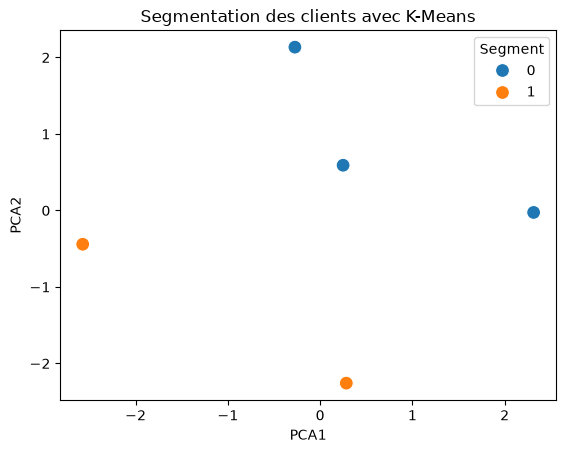

In [15]:
#Graphique:
sns.scatterplot(
    data=customer_features,
    x="PCA1",
    y="PCA2",
    hue="Segment",
    s=100
)

plt.title("Segmentation des clients avec K-Means")
plt.show()

In [16]:
#Profil des segments
segment_profile = (
    customer_features
    .groupby("Segment")[features]
    .mean()
)

display(segment_profile)

,Age,Total_Spent,Number_of_Purchases,Total_Quantity,Average_Sale_Value
Segment,,,,,
0,31.0,616.666667,1.333333,2.666667,86.666667
1,24.5,375.000000,0.500000,0.500000,60.000000


In [17]:
# Exemple de création des personas
def create_persona(row):
    if row["Total_Spent"] >= customer_features["Total_Spent"].median():
        return "Client à forte valeur"
    else:
        return "Client à faible valeur"

customer_features["Persona"] = customer_features.apply(
    create_persona,
    axis=1
)

display(
    customer_features[
        ["Customer_ID", "Segment", "Persona"]
    ]
)

,Customer_ID,Segment,Persona
0,2001,0,Client à forte valeur
1,2002,0,Client à forte valeur
2,2003,1,Client à faible valeur
3,2004,0,Client à forte valeur
4,2005,1,Client à faible valeur


In [18]:
#Sauvegarder :
customer_features.to_csv(
    "../data/processed/customer_features.csv",
    index=False
)